# Finance and Statistics / Monte Carlo Simulation Engine / Stochastic Modeling via GBM


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import seaborn as sns
import logging
from typing import List, Dict, Tuple, Optional

def setup_logging(level=logging.INFO):
    '''
    Configures the logging for the notebook.
    This helps in controlling output and avoiding sensitive information in stdout/stderr.
    '''
    logging.basicConfig(level=level, format='%(asctime)s - %(levelname)s - %(message)s')
    # Suppress yfinance messages if desired, though 'progress=False' already helpsn
    logging.getLogger('yfinance').setLevel(logging.CRITICAL)

setup_logging()
logger = logging.getLogger(__name__)

sns.set_theme(style="darkgrid")

ModuleNotFoundError: No module named 'yfinance'

In [ ]:
# --- GLOBAL CONFIGURATION AND CONSTANTS ---
START_DATE = '1950-01-01'
NUM_SIMULATIONS = 10000
NUM_DAYS_SINGLE_TICKER = 252  # Prediction horizon for single ticker (e.g., 1 year of trading days)
NUM_DAYS_MULTIPLE_TICKERS = 22 # Prediction horizon for multiple tickers (e.g., 1 month of trading days)
n
# --- DATA ACQUISITION FUNCTIONS ---
def get_stock_data(
    ticker_symbol: str | List[str], 
    start_date: str = START_DATEn
) -> Optional[pd.DataFrame]:
    '''
    Downloads historical stock data for a given ticker or list of tickers.n
n
    Args:n
        ticker_symbol (str | List[str]): The stock ticker symbol(s) (e.g., 'PLTR', ['MSFT', 'GOOGL']).
        start_date (str): The start date for historical data (format 'YYYY-MM-DD').
n
    Returns:
        Optional[pd.DataFrame]: A DataFrame with the historical data, or None if an error occurs.
    '''
    try:
        data = yf.download(
            ticker_symbol,
            start=start_date,
            group_by='ticker' if isinstance(ticker_symbol, list) else 'default',
            progress=False,
            # actions=True # To include dividends and stock splits if neededn
        )
        if data.empty:
            logger.warning(f"No data retrieved for ticker(s): {ticker_symbol}")
            return Nonen
        logger.info(f"Successfully downloaded data for {ticker_symbol} from {start_date}.")
        return datan
    except Exception as e:
        logger.error(f"Error downloading data for {ticker_symbol}: {e}")
        return Nonen

def calculate_returns(df: pd.DataFrame, ticker: str | Tuple[str, ...]) -> pd.DataFrame:
    '''
    Calculates the percentage change (returns) for the 'Close' price of a stock.
    Handles both single and multi-level columns from yfinance.

    Args:
        df (pd.DataFrame): DataFrame containing stock data.
        ticker (str | Tuple[str, ...]): The ticker symbol or tuple representing the column.

    Returns:
        pd.DataFrame: DataFrame with a new 'Returns' column.
    '''
    if isinstance(ticker, str): # Single ticker casen
        close_col = ('Close',)
        if close_col not in df.columns: # Adjust for yfinance default output for single ticker (no multi-index)n
            close_col = 'Close'
    elif isinstance(ticker, tuple): # Multi-ticker case, yfinance creates multi-index columnsn
        close_col = (ticker[0], 'Close') # Assuming ticker is ('PLTR',) -> ('PLTR', 'Close')n
    else: # Fallback for mis_tickers iteration which passes stringn
        close_col = (ticker, 'Close')
    n
    # Check if the column exists before calculating returnsn
    if close_col in df.columns:
        # Address FutureWarning by explicitly setting fill_method=None or handling NaNs beforehandn
        df['Returns'] = df[close_col].pct_change(fill_method=None)
        logger.info(f"Calculated returns for {ticker}.")
    else:
        logger.error(f"Close price column {close_col} not found for {ticker}.")
    return df

# Un Ticker

In [ ]:
ticker = "PLTR"
df = yf.download(ticker, start='1950-01-01', group_by='ticker', progress=False)
# Calcular los retornos
df["Returns"] = df[("PLTR", "Close")].pct_change()


[*********************100%***********************]  1 of 1 completed

Primer elemento del DataFrame:n
Ticker      PLTR                              n
Price       Open   High   Low Close     Volumen
Date                                          n
2020-09-30  10.0  11.41  9.11   9.5  338584400n

n

In [ ]:
num_simulations=10000
num_days=252 #predict horizonn
last_price=df[('PLTR', 'Close')].iloc[-1]

simulation_df=np.zeros((num_days,num_simulations))
mu=df["Returns"].mean()
sigma=df["Returns"].std()

In [ ]:
for i in range(num_simulations):
  price_list=[last_price]
  for j in range(num_days):
    price=price_list[-1] * np.exp((mu - 0.5 * sigma**2) + sigma * np.random.normal())
    price_list.append(price)
  simulation_df[:,i]=price_list[1:]
n
final_prices=simulation_df[-1,:]
median_final_prices=np.median(final_prices)
n
most_likely_price_index=np.argmin(np.abs(final_prices-median_final_prices))
most_likely_price_simulation=simulation_df[:,most_likely_price_index]

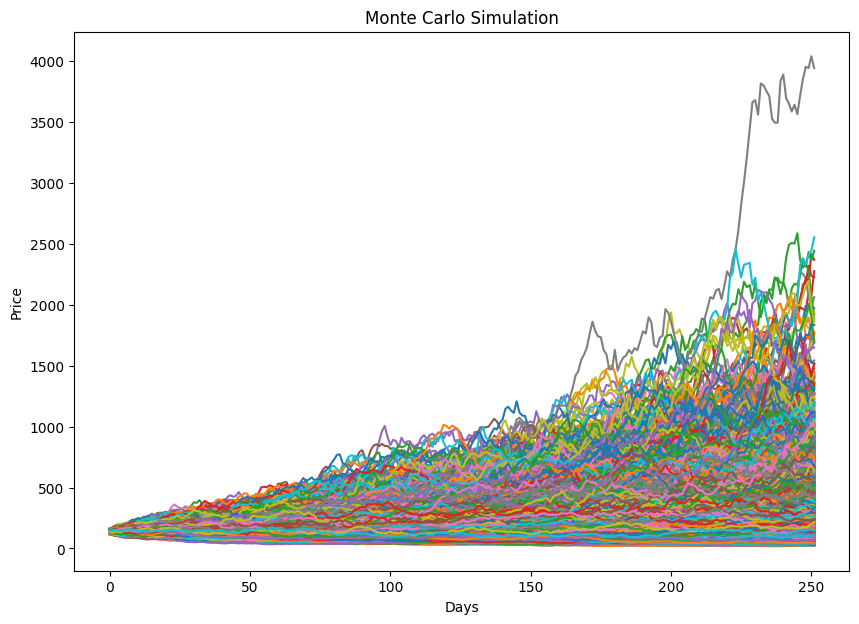

The most likely price for PLTR is: 223.09n
Todays close price for PLTR on 2026-05-08 is: 137.80n

In [ ]:
plt.figure(figsize=(10,7))
plt.plot(simulation_df, alpha=0.25)
plt.title("Monte Carlo Simulation")
plt.xlabel("Days")
plt.ylabel("Price")
plt.show()
n
print(f"Resumen de la simulación para {ticker}:")
print(f"- Precio más probable al final del horizonte: {most_likely_price_simulation[-1]:.2f}")
print(f"- Mediana de precios finales: {median_final_prices:.2f}")

# Varios Tickers

In [ ]:
mis_tickers = ["PLTR",
               "MSFT",
               "GOOGL",
               "META",
               "LMT",
               "CVX"]

df2 = yf.download(mis_tickers, start='1950-01-01', group_by='ticker', progress=False)
for ticker in mis_tickers:
    df2[(ticker, 'Returns')] = df2[(ticker, 'Close')].pct_change()

[*********************100%***********************]  6 of 6 completedn
C:UsersrvilcaromeroAppDataLocalTempipykernel_1745222392461.py:10: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.n
  df2[(ticker, 'Returns')] = df2[(ticker, 'Close')].pct_change()n

In [ ]:
num_simulations = 10000
num_days = 22  # predict horizonn

# Dictionaries to store results for each tickern
all_ticker_simulation_dfs = {}
all_ticker_most_likely_prices = {}
all_ticker_median_final_prices = {}

--------- Simulating for ['PLTR', 'MSFT', 'GOOGL', 'META', 'LMT', 'CVX'] ---------n

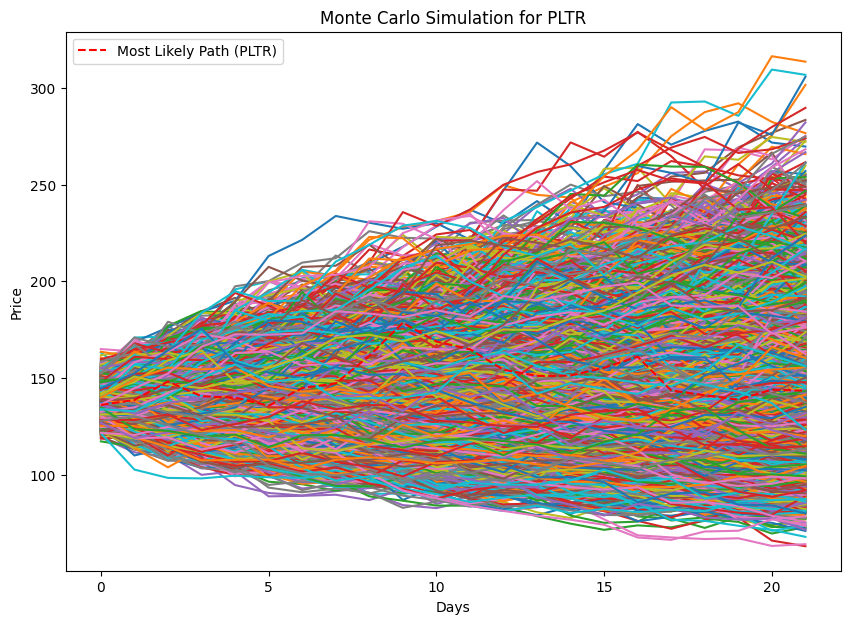

-------- Results for PLTR ---------n
Todays close price for PLTR on 2026-05-08 is: $137.80n
Median Final Price: $143.48n
Most Likely Final Price: $143.48n
---------------------------------------------------------------------------n

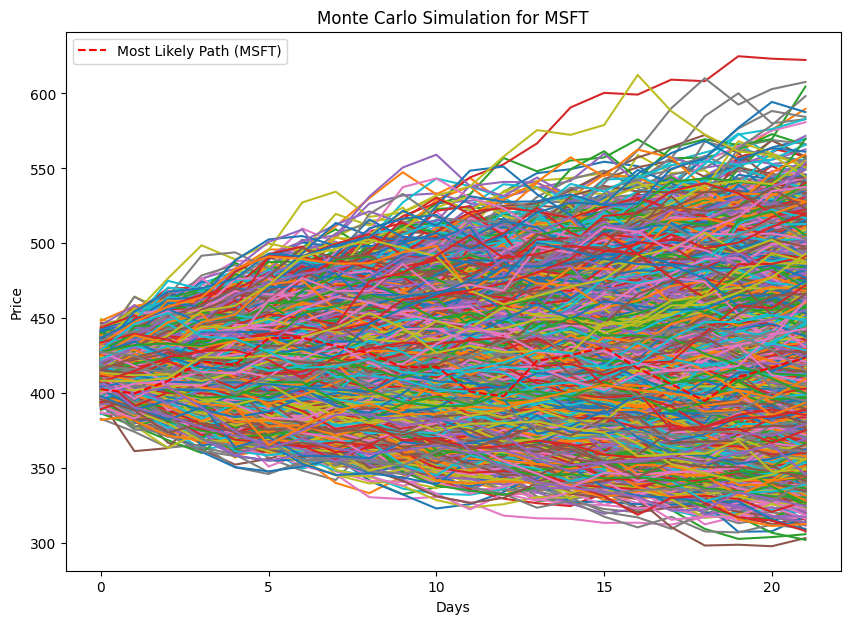

-------- Results for MSFT ---------n
Todays close price for MSFT on 2026-05-08 is: $415.12n
Median Final Price: $423.62n
Most Likely Final Price: $423.61n
---------------------------------------------------------------------------n

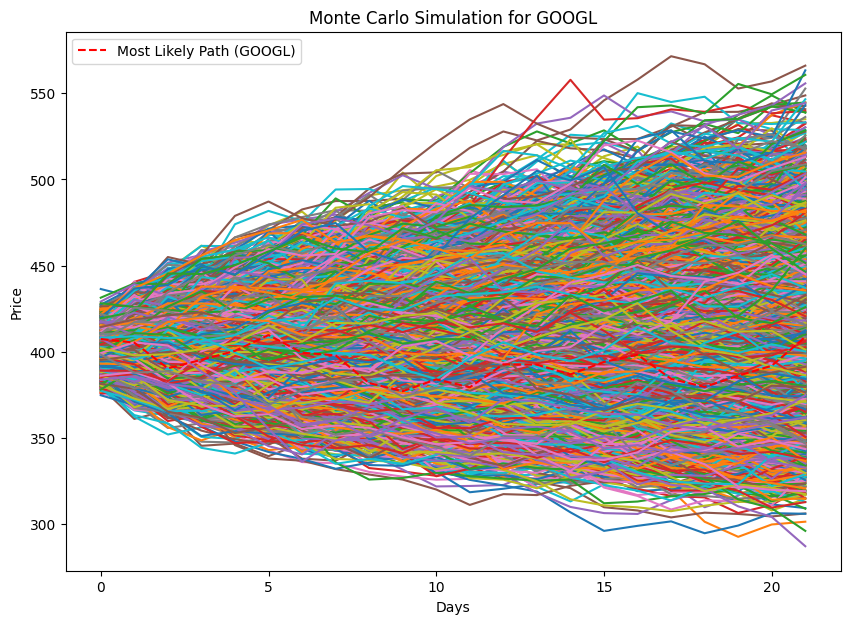

-------- Results for GOOGL ---------n
Todays close price for GOOGL on 2026-05-08 is: $400.80n
Median Final Price: $408.49n
Most Likely Final Price: $408.49n
---------------------------------------------------------------------------n

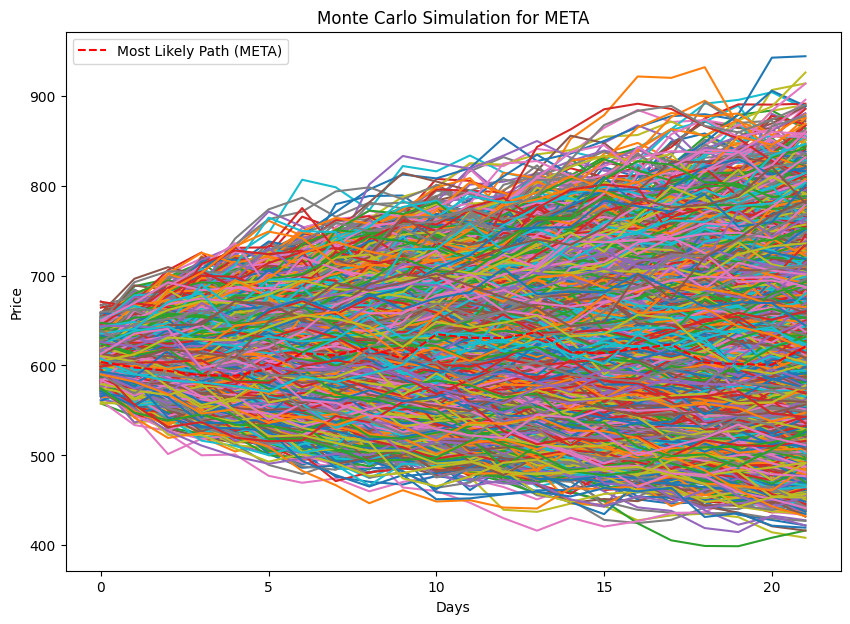

-------- Results for META ---------n
Todays close price for META on 2026-05-08 is: $609.63n
Median Final Price: $620.99n
Most Likely Final Price: $620.99n
---------------------------------------------------------------------------n

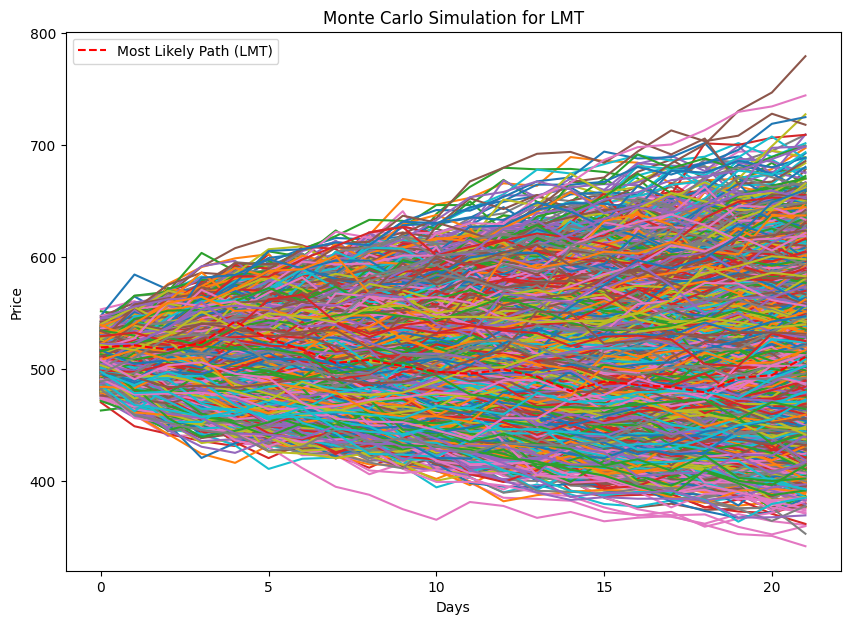

-------- Results for LMT ---------n
Todays close price for LMT on 2026-05-08 is: $506.51n
Median Final Price: $510.56n
Most Likely Final Price: $510.56n
---------------------------------------------------------------------------n

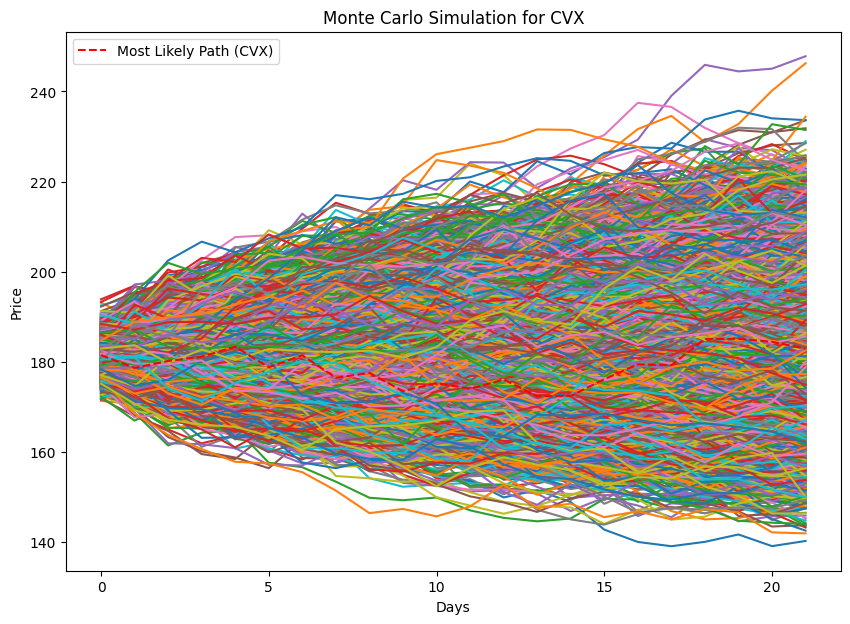

-------- Results for CVX ---------n
Todays close price for CVX on 2026-05-08 is: $181.62n
Median Final Price: $182.88n
Most Likely Final Price: $182.88n
---------------------------------------------------------------------------n

In [ ]:
print(f"--------- Simulating for {mis_tickers} ---------")
for current_ticker in mis_tickers:
        # Get ticker-specific parametersn
    last_price = df2[(current_ticker, 'Close')].iloc[-1]
n
    # Calculate mu and sigma for the current tickern
    ticker_returns = df2[(current_ticker, 'Returns')].dropna() # Drop NaN for calculationn
    mu = ticker_returns.mean()
    sigma = ticker_returns.std()
n
    # Initialize simulation_df for the current tickern
    simulation_df = np.zeros((num_days, num_simulations))
n
    # Run Monte Carlo simulationn
    for i in range(num_simulations):
        price_list = [last_price]
        for j in range(num_days):
            price = price_list[-1] * np.exp((mu - 0.5 * sigma**2) + sigma * np.random.normal())
            price_list.append(price)
        simulation_df[:, i] = price_list[1:]
n
    # Analyze resultsn
    final_prices = simulation_df[-1, :]
    median_final_prices = np.median(final_prices)
    most_likely_price_index = np.argmin(np.abs(final_prices - median_final_prices))
    most_likely_price_simulation = simulation_df[:, most_likely_price_index]
n
    # Store resultsn
    all_ticker_simulation_dfs[current_ticker] = simulation_df
    all_ticker_most_likely_prices[current_ticker] = most_likely_price_simulation[-1]
    all_ticker_median_final_prices[current_ticker] = median_final_prices
n
    # Plotting for the current tickern
    plt.figure(figsize=(10, 7))
    plt.plot(simulation_df, alpha=0.2)
    plt.plot(most_likely_price_simulation, color='red', linestyle='--', label=f'Most Likely Path ({current_ticker})')
    plt.title(f"Monte Carlo Simulation for {current_ticker}")
    plt.xlabel("Days")
    plt.ylabel("Price")
    plt.legend()
    plt.show()
n
    print(f"-------- Results for {current_ticker} ---------")
    print(f"Median Final Simulated Price: ${all_ticker_median_final_prices[current_ticker]:.2f}")
    print(f"Most Likely Final Simulated Price: ${all_ticker_most_likely_prices[current_ticker]:.2f}")
    print("-" * 75)

In [ ]:
# Consolidated summary of results for all tickersn
print(f"\n--- Consolidated Analysis for All Tickers (Prediction Horizon: {num_days} days, Simulations: {num_simulations}) ---")
for ticker in mis_tickers:
    simulated_price = all_ticker_most_likely_prices[ticker]
    print(f"{ticker}: Most Likely Simulated Final Price: {simulated_price:.3f}")

n
--- Consolidated Analysis for All Tickers (Prediction Horizon: 22 days, Simulations: 10000) ---n
PLTR: Most Likely Simulated Final Price: 143.483 | Today's Current Price: 137.800n
MSFT: Most Likely Simulated Final Price: 423.614 | Today's Current Price: 415.120n
GOOGL: Most Likely Simulated Final Price: 408.491 | Today's Current Price: 400.800n
META: Most Likely Simulated Final Price: 620.990 | Today's Current Price: 609.630n
LMT: Most Likely Simulated Final Price: 510.556 | Today's Current Price: 506.510n
CVX: Most Likely Simulated Final Price: 182.878 | Today's Current Price: 181.620n

In [ ]:

# Create a list to store the resultsn
results = []

# Collect data for each tickern
for ticker in mis_tickers:n
    simulated_price = all_ticker_most_likely_prices[ticker]/
    results.append({
        "Ticker": ticker,
        "Most Likely Simulated Final Price": round(simulated_price, 3)
    })

# Create a DataFrame from the results
results_df = pd.DataFrame(results)

# Display the tablen
print(f"\n--- Consolidated Analysis for All Tickers (Prediction Horizon: {num_days} days, Simulations: {num_simulations}) ---")
print(results_df.to_string(index=False))

n
--- Consolidated Analysis for All Tickers (Prediction Horizon: 22 days, Simulations: 10000) ---n
Ticker  Most Likely Simulated Final Price  Today's Current Pricen
  PLTR                            143.483                 137.80n
  MSFT                            423.614                 415.12n
 GOOGL                            408.491                 400.80n
  META                            620.990                 609.63n
   LMT                            510.556                 506.51n
   CVX                            182.878                 181.62n

## Distribución de Precios Finales Simulados

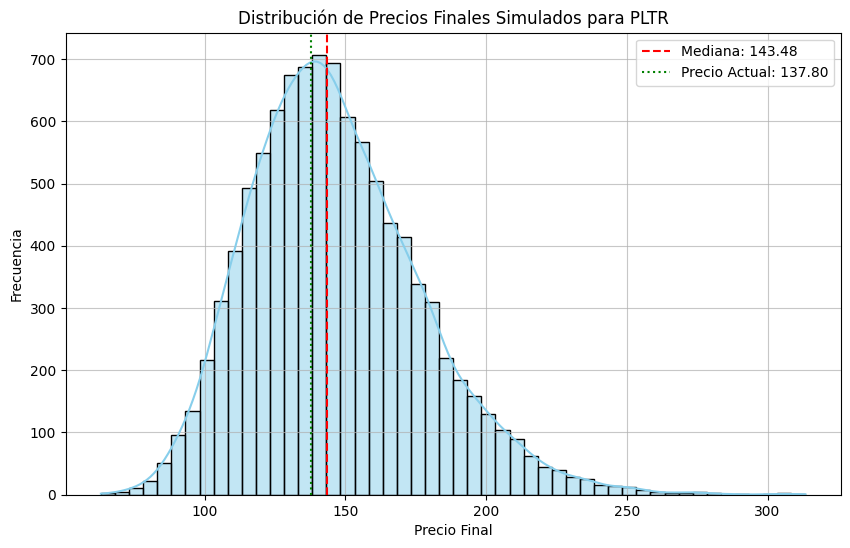

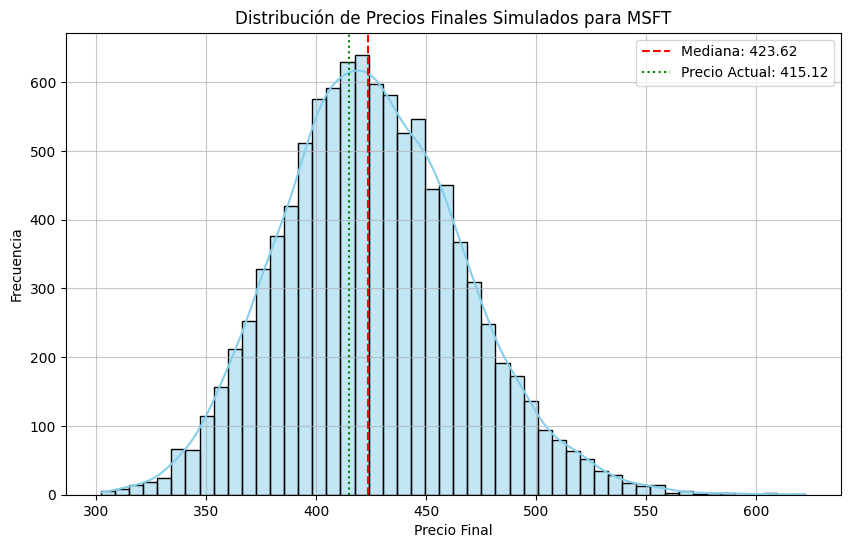

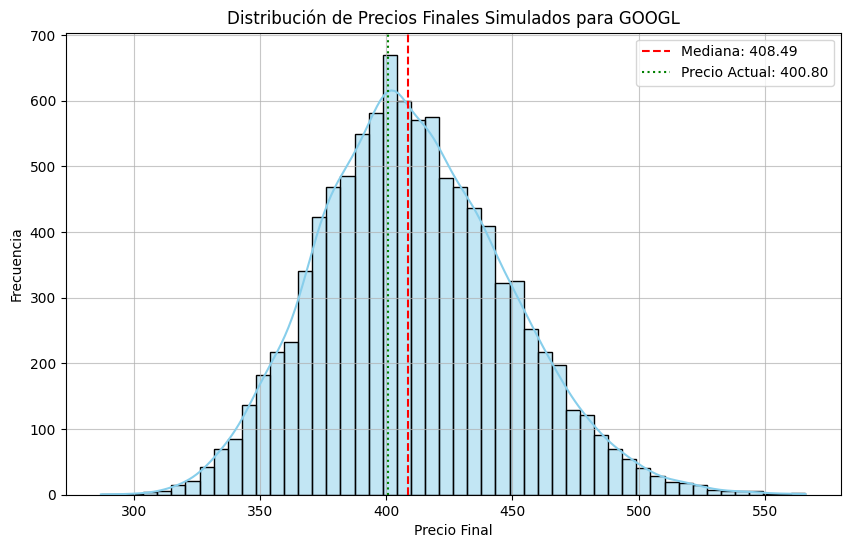

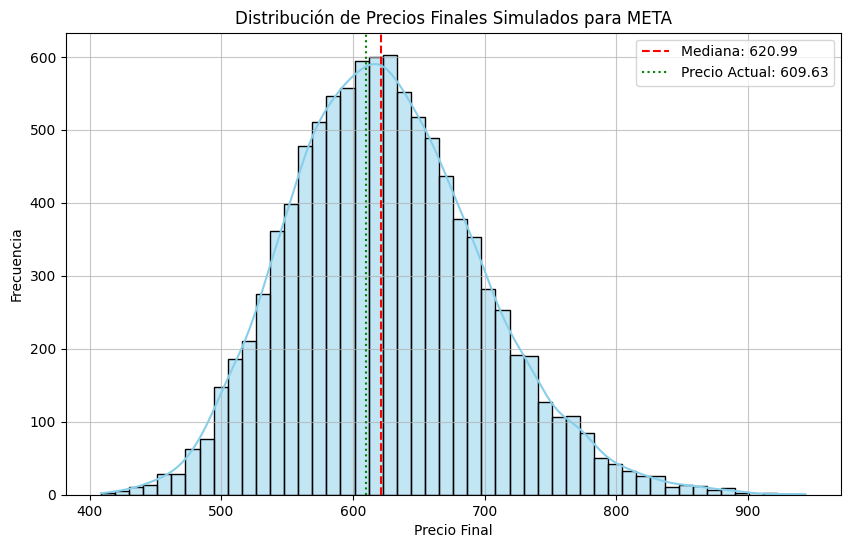

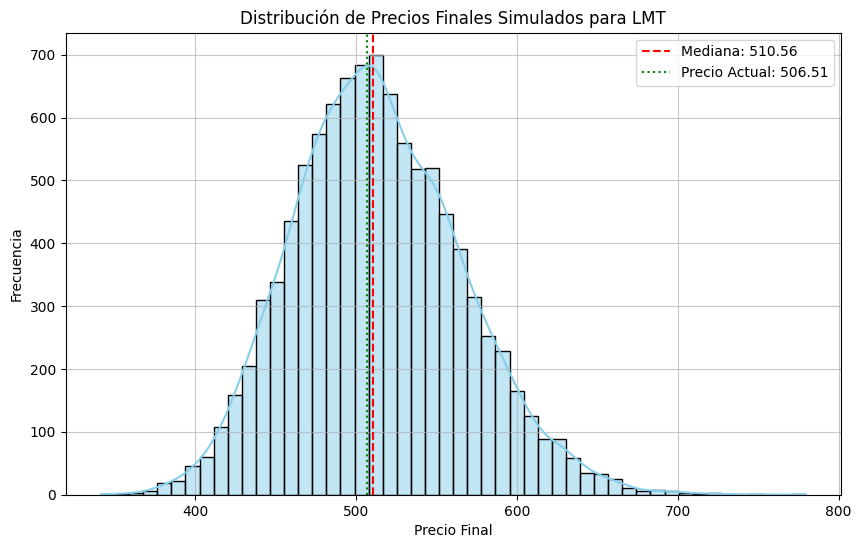

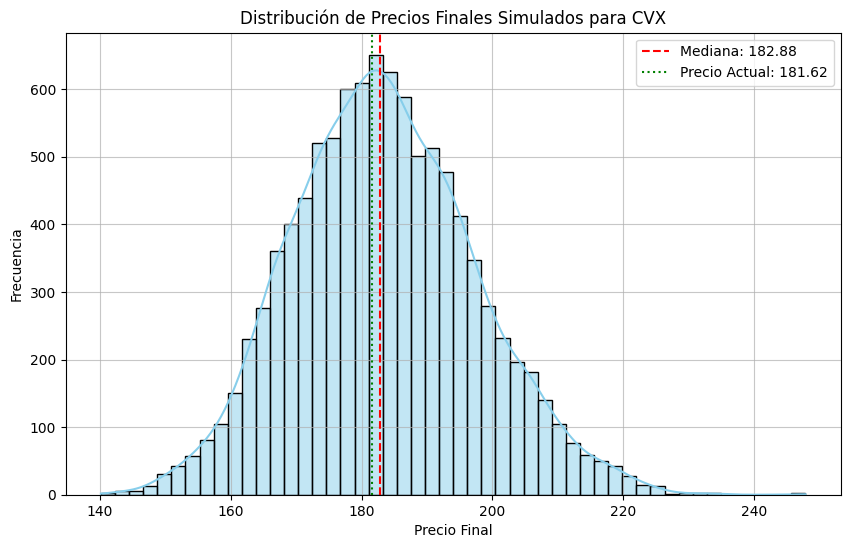

In [ ]:
for ticker in mis_tickers:
    plt.figure(figsize=(10, 6))
    final_prices = all_ticker_simulation_dfs[ticker][-1, :]
    sns.histplot(final_prices, bins=50, kde=True, color='skyblue')
    plt.title(f'Distribución de Precios Finales Simulados para {ticker}')
    plt.xlabel('Precio Final')
    plt.ylabel('Frecuencia')
    plt.axvline(all_ticker_median_final_prices[ticker], color='red', linestyle='--', label=f'Mediana: {all_ticker_median_final_prices[ticker]:.2f}')
    plt.legend()
    plt.grid(True, alpha=0.7)
    plt.show()

## Intervalo de Confianza del 95% para los Precios Finales Simulados

In [ ]:
print("--- 95% Confidence Interval for Simulated Final Prices ---")
for ticker in mis_tickers:
    final_prices = all_ticker_simulation_dfs[ticker][-1, :]
    lower_bound = np.percentile(final_prices, 2.5)
    upper_bound = np.percentile(final_prices, 97.5)
    print(f"{ticker}: 95% CI: [{lower_bound:.3f}, {upper_bound:.3f}]")

--- 95% Confidence Interval for Simulated Final Prices ---n
PLTR: 95% CI: [95.841, 214.885]n
MSFT: 95% CI: [349.765, 513.104]n
GOOGL: 95% CI: [343.207, 490.182]n
META: 95% CI: [495.686, 780.871]n
LMT: 95% CI: [418.988, 624.845]n
CVX: 95% CI: [157.746, 212.198]n